In [1]:
import nilearn
import pandas
import nibabel

print("All good")

All good



# Beginner notebook: getting **real fMRI + behavior/confounds data** on Ubuntu in VS Code

This notebook is for **learning**, not just copy/paste.

We will use a **real public dataset** that Nilearn fetches from a dataset whose original source is **OpenNeuro dataset `ds000228`**. Nilearn documents that `fetch_development_fmri` returns:

- `func`: 4D fMRI NIfTI files
- `confounds`: TSV files
- `phenotypic`: a pandas table with age, age group, gender, handedness
- `t_r`: repetition time

The idea is simple:

1. download a small real dataset
2. inspect the files
3. open the behavioral / subject table
4. open the confounds table
5. open one fMRI image
6. extract regional time series
7. build a simple connectivity matrix

---

## What you will learn

- what `.nii.gz`, `.tsv`, and metadata tables actually do
- how subject-level information is linked to imaging data
- how to move from a brain image to a connectivity matrix
- how this connects to your long-term **insula ↔ DMN / anxiety** goal

---

## Before you run the notebook: Ubuntu + VS Code setup

Open a **terminal in your project folder** and run these commands **one line at a time**:

```bash
mkdir -p ~/fmri_learning
cd ~/fmri_learning

python3 -m venv .venv
source .venv/bin/activate

python -m pip install --upgrade pip
pip install notebook ipykernel pandas numpy matplotlib nibabel nilearn scikit-learn

python -m ipykernel install --user --name=fmri-learning --display-name "Python (fmri-learning)"
```

Then in **VS Code**:

1. open this folder
2. open this notebook
3. use **Select Kernel** at the top right
4. choose **Python (fmri-learning)**

If a cell fails because a package is missing, it usually means VS Code is using the wrong kernel.



## 1) Imports

This cell loads the Python tools we need.

- `pandas` for tables
- `pathlib` for file paths
- `nibabel` for reading NIfTI images
- `matplotlib` for simple plots
- `nilearn` for downloading and analyzing neuroimaging data


In [17]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from nilearn import datasets, plotting
from nilearn.maskers import NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure

print("Imports loaded.")


Imports loaded.



## 2) Choose where the dataset will live

I strongly recommend keeping downloaded data in a dedicated folder.


In [19]:
from pathlib import Path

# Set data directory INSIDE your project
data_dir = Path.cwd() / "data"

# Create the folder if it doesn't exist
data_dir.mkdir(parents=True, exist_ok=True)

print("Data folder:", data_dir)


Data folder: /home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data



## 3) Download a **real public fMRI dataset**

We are using `fetch_development_fmri(n_subjects=2)` so the first download is manageable.

Why this dataset is good for learning:

- it is real fMRI data
- it includes **confounds** (`.tsv`)
- it includes a **phenotypic table** (behavior / demographics)
- it is small enough for a beginner workflow

> Important: the first download can take a while depending on your internet speed.


In [20]:

dev = datasets.fetch_development_fmri(
    n_subjects=2,
    data_dir=str(data_dir),
    reduce_confounds=True,
    verbose=1
)

print("Keys returned by Nilearn:", list(dev.keys()))
print("TR (seconds):", dev["t_r"])
print("Number of fMRI files:", len(dev["func"]))
print("Number of confound files:", len(dev["confounds"]))


[fetch_development_fmri] Added README.md to /home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data
[fetch_development_fmri] Dataset created in /home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data/development_fmri
[fetch_development_fmri] Added README.md to /home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data/development_fmri
[fetch_development_fmri] Dataset created in /home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data/development_fmri/development_fmri
[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...
[fetch_development_fmri]  ...done. (3 seconds, 0 min)

[fetch_development_fmri] Dataset found in /home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data/development_fmri/development_fmri
[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3df4712b400183b7092/ ...
[fetch_development_fmri]  ...done. (3 seconds, 0 min)

[fetch_development_fmri] Downloading d


## 4) Look at what came back

A very important habit in neuroimaging is: **inspect the object before you analyze it**.


In [21]:

print("Example fMRI file:")
print(dev["func"][0])

print("\nExample confounds file:")
print(dev["confounds"][0])

print("\nPhenotypic table type:")
print(type(dev["phenotypic"]))


Example fMRI file:
/home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

Example confounds file:
/home/john-walkey/Data/Research/insula_dmn_project/fmri_learning/data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv

Phenotypic table type:
<class 'pandas.DataFrame'>



## 5) Inspect the participant / phenotypic table

This is the closest thing in this tutorial to your **behavior / subject traits** table.

For this dataset, Nilearn says the table contains:
- age
- age group
- gender
- handedness

In other datasets, this kind of table may contain:
- anxiety scores
- depression scores
- IQ
- education
- diagnosis
- task performance


In [22]:

phenotypic = dev["phenotypic"].copy()
display(phenotypic)


,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness
122,sub-pixar123,27.060000,Adult,adult,F,R
0,sub-pixar001,4.774812,4yo,child,M,R



### Pause and interpret

This table is conceptually the same kind of structure you would later use for:

- **trait anxiety**
- **state anxiety**
- **rumination**
- **clinical group**
- **reaction time**
- **physiology summaries**

The key idea is always the same:

**subject ID / row in the table** ↔ **that subject's brain image**



## 6) Open one confounds TSV file

A confounds file is not your main behavioral variable.  
It contains nuisance variables that help control for noise, such as motion and physiological proxies.

This is important because in fMRI you almost never want to trust the raw signal blindly.


In [7]:

confounds_path = Path(dev["confounds"][0])
confounds = pd.read_csv(confounds_path, sep="\t")
print("Confounds shape:", confounds.shape)
display(confounds.head())


Confounds shape: (168, 15)


,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,framewise_displacement,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,a_comp_cor_04,a_comp_cor_05,csf,white_matter
0,-0.000233,-0.076885,0.062321,0.000732,0.000352,0.000841,0.000000,-0.099871,-0.007286,0.001780,-0.008073,0.030945,-0.022393,439.699409,451.645460
1,-0.006187,-0.078395,0.056773,0.000112,0.000187,0.000775,0.055543,-0.019437,-0.042308,0.016735,-0.012099,0.088777,-0.006171,439.471640,451.103437
2,-0.000227,-0.069893,0.083102,0.000143,0.000364,0.000716,0.054112,0.009096,-0.053206,-0.030388,-0.052925,0.019922,0.014776,439.744498,450.981505
3,0.002492,-0.074707,0.060337,0.000202,0.000818,0.000681,0.057667,0.060195,-0.083195,0.003578,-0.037011,0.026946,0.002505,440.772620,450.600261
4,-0.000226,-0.084204,0.085079,0.000183,0.000548,0.000682,0.051438,0.049833,-0.089819,-0.020825,-0.079329,0.008516,-0.000938,440.115442,450.678959



### What you are seeing

Each **row** usually corresponds to one fMRI time point (one TR).  
Each **column** is a nuisance regressor, such as:

- motion in x/y/z
- rotations
- framewise displacement
- white matter signal
- CSF signal
- aCompCor components

Later, when you do your own research, these are part of the quality-control story.



## 7) Open one fMRI file (`.nii.gz`) and inspect it

A functional MRI file is a 4D image:

- x
- y
- z
- time


In [8]:

fmri_path = Path(dev["func"][0])
img = nib.load(str(fmri_path))

print("File:", fmri_path.name)
print("Image shape:", img.shape)
print("Number of dimensions:", len(img.shape))
print("Voxel sizes / zooms:", img.header.get_zooms())


File: sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Image shape: (50, 59, 50, 168)
Number of dimensions: 4
Voxel sizes / zooms: (np.float32(4.0), np.float32(4.0), np.float32(4.0), np.float32(1.0))



### How to interpret the shape

If the shape looks like something such as:

```python
(49, 58, 47, 168)
```

that means:

- 49 voxels in x
- 58 voxels in y
- 47 voxels in z
- 168 time points

So this is not one picture.  
It is a **movie of the brain over time**.



## 8) Show one anatomical slice from one time point

This is just to make the data feel real and concrete.


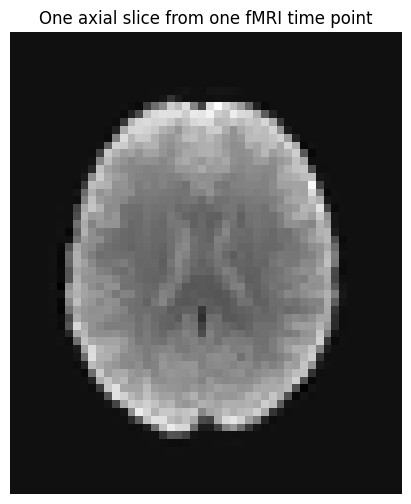

In [9]:

data = img.get_fdata()
middle_time = data.shape[3] // 2
middle_slice = data.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(data[:, :, middle_slice, middle_time].T, origin="lower", cmap="gray")
plt.title("One axial slice from one fMRI time point")
plt.axis("off")
plt.show()



## 9) Use an atlas to summarize the brain into regions

Voxel-wise analysis is possible, but for learning it is easier to reduce the brain into named regions.

We will use the **MSDL functional atlas** from Nilearn.  
This gives us region maps and region labels.

This step is very close in spirit to your long-term goal:
- later you will care about **insula**
- and about **DMN-related regions**
- and the correlations among their time series


In [10]:

msdl = datasets.fetch_atlas_msdl(data_dir=str(data_dir))
print("Atlas maps file:", msdl.maps)
print("Number of labels:", len(msdl.labels))
print("First 15 labels:", msdl.labels[:15])


[fetch_atlas_msdl] Dataset found in /home/john-walkey/fmri_learning/data/msdl_atlas
Atlas maps file: /home/john-walkey/fmri_learning/data/msdl_atlas/MSDL_rois/msdl_rois.nii
Number of labels: 39
First 15 labels: ['L Aud', 'R Aud', 'Striate', 'L DMN', 'Med DMN', 'Front DMN', 'R DMN', 'Occ post', 'Motor', 'R DLPFC', 'R Front pol', 'R Par', 'R Post Temp', 'Basal', 'L Par']



## 10) Extract regional time series from the first subject

This converts the 4D fMRI image into a 2D matrix:

- rows = time points
- columns = brain regions


In [11]:

masker = NiftiMapsMasker(
    maps_img=msdl.maps,
    standardize="zscore_sample",
    detrend=True,
    t_r=dev["t_r"],
    memory=str(data_dir / "nilearn_cache"),
    verbose=0
)

time_series = masker.fit_transform(str(fmri_path), confounds=confounds)

print("Time-series shape:", time_series.shape)
print("This means:")
print(f"- {time_series.shape[0]} time points")
print(f"- {time_series.shape[1]} atlas regions")


Time-series shape: (168, 39)
This means:
- 168 time points
- 39 atlas regions


/tmp/ipykernel_7407/2820460376.py:10: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  time_series = masker.fit_transform(str(fmri_path), confounds=confounds)



## 11) Find labels related to the insula and DMN

This is not yet a perfect neuroscientific definition of the DMN, but it helps you see how atlas labels connect to your question.


In [12]:

labels = pd.Series(msdl.labels, name="label")
insula_like = labels[labels.str.contains("insula", case=False, regex=False)]
dmn_like = labels[labels.str.contains("default", case=False, regex=False)]

print("Labels containing 'insula':")
display(insula_like)

print("\nLabels containing 'default':")
display(dmn_like)


Labels containing 'insula':


Series([], Name: label, dtype: str)


Labels containing 'default':


Series([], Name: label, dtype: str)


### Important note

Atlases do **not** all use the same naming scheme.

So in future work you may need to choose an atlas carefully depending on whether you want:
- anatomical precision
- network labels
- cortical parcels
- subcortical regions

That is normal. It is part of the craft.



## 12) Compute a simple functional connectivity matrix

This asks:

> which regional time series rise and fall together?

For now we will use **Pearson correlation**.


In [13]:

connectivity_measure = ConnectivityMeasure(kind="correlation")
corr_matrix = connectivity_measure.fit_transform([time_series])[0]

print("Connectivity matrix shape:", corr_matrix.shape)
print("Minimum correlation:", np.min(corr_matrix))
print("Maximum correlation:", np.max(corr_matrix))


Connectivity matrix shape: (39, 39)
Minimum correlation: -0.4715741272545698
Maximum correlation: 1.0


/tmp/ipykernel_7407/3387381792.py:2: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  corr_matrix = connectivity_measure.fit_transform([time_series])[0]



## 13) Visualize the connectivity matrix

Each cell is the correlation between one region and another.


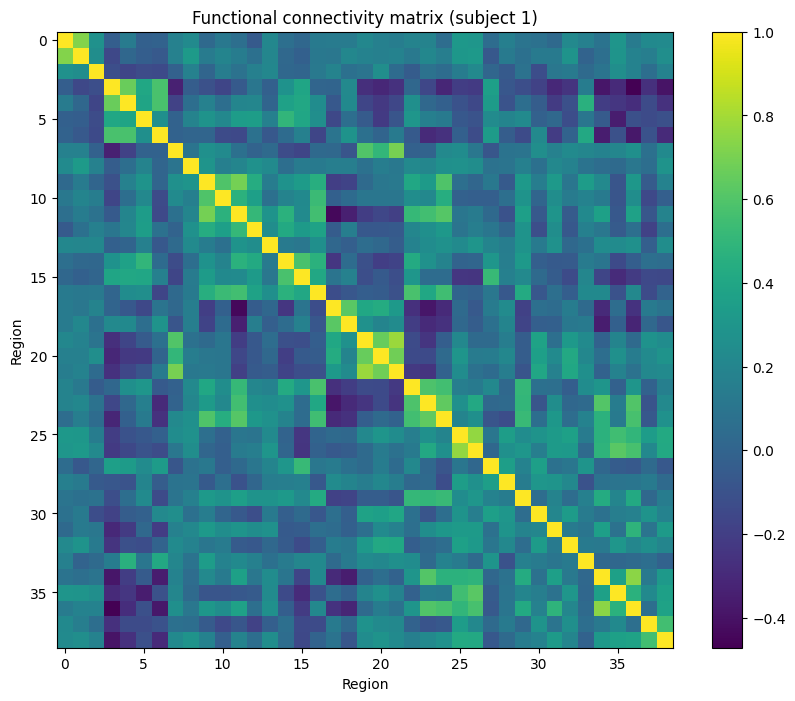

In [14]:

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, interpolation="nearest")
plt.title("Functional connectivity matrix (subject 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.colorbar()
plt.show()



## 14) Pull out a few named regions and inspect them more directly

This cell looks for a small set of labels that are easy to discuss.


In [15]:

interesting_terms = ["insula", "default", "cingulate", "parietal", "frontal"]
matches = []

for i, label in enumerate(msdl.labels):
    low = label.lower()
    if any(term in low for term in interesting_terms):
        matches.append((i, label))

matches_df = pd.DataFrame(matches, columns=["index", "label"])
display(matches_df.head(30))
print("Number of matched labels:", len(matches_df))


,index,label


Number of matched labels: 0



## 15) Save a clean CSV copy of the phenotypic table

This is useful because it gives you a plain spreadsheet you can inspect outside Python.


In [16]:

phenotype_out = data_dir / "phenotypic_table.csv"
phenotypic.to_csv(phenotype_out, index=False)
print("Saved to:", phenotype_out)


Saved to: /home/john-walkey/fmri_learning/data/phenotypic_table.csv



## 16) What this notebook has *actually* taught you

You have now done the following with **real public data**:

- downloaded a real fMRI dataset
- inspected the returned file paths
- opened a phenotypic table
- opened a confounds TSV
- loaded a `.nii.gz` fMRI image
- checked its 4D shape
- extracted region-wise time series
- computed a simple connectivity matrix

That is the core logic of databank-based fMRI work.

---

## How this maps to your future anxiety project

Later, the workflow becomes:

1. choose a dataset that contains **anxiety-related variables**
2. load the subject table
3. extract network connectivity per person
4. test whether:
   - insula ↔ DMN connectivity predicts anxiety
   - or network organization differs by anxiety level

This notebook is the **mechanical foundation** for that.



## 17) Exact terminal commands to re-open this project later

From Ubuntu terminal:

```bash
cd ~/fmri_learning
source .venv/bin/activate
code .
```

If you want to launch Jupyter directly from terminal instead of VS Code:

```bash
cd ~/fmri_learning
source .venv/bin/activate
jupyter notebook
```



## 18) If something goes wrong

### Problem: `ModuleNotFoundError`
Usually means your notebook is attached to the wrong kernel.

### Problem: very slow first cell
First dataset download can be slow; later runs are much faster because files are cached locally.

### Problem: plots do not appear
Make sure the cell actually ran, and try restarting the kernel then **Run All**.

### Problem: dataset folder is confusing
That is normal. Spend time just reading file names and paths. That is part of learning BIDS-style thinking.



## 19) Best way to study this notebook

Do **not** rush.

For each code cell, ask yourself:

1. what object came back?
2. is it a table, path, image, or matrix?
3. what are the rows?
4. what are the columns?
5. how does this relate to the scientific question?

That is how you move from “running code” to “understanding fMRI research”.
